# Inverse-Diagnostic Demo

Этот notebook является frontend к продуктовому pipeline `run_inverse_diagnostic_cycle(...)`.
Вся бизнес-логика (observation mapping, canonicalization, HMM decoding, recommendation) выполняется в Python-модуле `src/hidden_patterns_combat/app/inverse_diagnostic_cycle.py`.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from hidden_patterns_combat.app.inverse_diagnostic_cycle import run_inverse_diagnostic_cycle
from hidden_patterns_combat.ui.inverse_notebook import (
    load_inverse_artifacts,
    display_inverse_report,
    display_inverse_plots,
)

In [2]:
repo_root = Path.cwd()
if not (repo_root / "src").exists() and (repo_root.parent / "src").exists():
    repo_root = repo_root.parent

input_path = repo_root / "data" / "raw" / "episodes.xlsx"
output_dir = repo_root / "artifacts" / "inverse_diagnostic_notebook"
sheet_names = None  # например: ["Общее"]
n_states = 3
topology_mode = "left_to_right"
retrain = True
model_path = None

In [3]:
result = run_inverse_diagnostic_cycle(
    input_path=input_path,
    output_dir=output_dir,
    sheet_names=sheet_names,
    n_states=n_states,
    topology_mode=topology_mode,
    retrain=retrain,
    model_path=model_path,
    verbose=True,
)
result

[1/7] Preprocessing input workbook...
[2/7] Building canonical observations and episode table...
[3/7] Training/loading inverse diagnostic HMM...
[4/7] Viterbi decoding and posterior profile...
[5/7] Rendering report and plots...
[6/7] Finalizing outputs...
[7/7] Inverse diagnostic cycle completed.


InverseDiagnosticResult(input_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/data/raw/episodes.xlsx', output_dir='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook', cleaned_data_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/cleaned/cleaned_tidy.csv', canonical_episode_table_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/cleaned/canonical_episode_table.csv', observed_sequence_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/cleaned/observed_sequence.csv', hidden_feature_layer_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/features/hidden_state_features.csv', episode_analysis_path='/Users/dmitryaleshkin/Documents/hidden-patterns-combat/artifacts/inverse_diagnostic_notebook/diagnostics/episode_analysis.csv', state_profile_path='

In [4]:
artifacts = load_inverse_artifacts(output_dir)
display(Markdown("## Run Summary"))
display(pd.Series(result.as_dict(), name="value").to_frame())
display(Markdown("## Episode Analysis Preview"))
display(artifacts.episode_analysis.head(20))
display(Markdown("## State Profile Preview"))
display(artifacts.state_profile.head(20))
display(Markdown("## Quality Diagnostics"))
display(pd.json_normalize(artifacts.quality_diagnostics, sep=".").T.rename(columns={0: "value"}))

## Run Summary

,value
input_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
output_dir,/Users/dmitryaleshkin/Documents/hidden-pattern...
cleaned_data_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
canonical_episode_table_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
observed_sequence_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
hidden_feature_layer_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
episode_analysis_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
state_profile_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
quality_diagnostics_path,/Users/dmitryaleshkin/Documents/hidden-pattern...
report_path,/Users/dmitryaleshkin/Documents/hidden-pattern...


## Episode Analysis Preview

,athlete_name,athlete_id,sheet_name,weight_class,episode_id,sequence_id,sequence_quality_flag,sequence_resolution_type,episode_time_sec,pause_time_sec,...,is_train_eligible,source_row_index,source_record_id,hidden_state,hidden_state_name,p_state_0,p_state_1,p_state_2,confidence,observed_result
0,Акрамов Б.Б.,ath_4591627b59ec,48,NaN,1,48::ath_4591627b59ec::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,0,48::0,1,state_0,0.190651,0.807709,0.001640,0.807709,1.0
1,Акрамов Б.Б.,ath_4591627b59ec,48,NaN,2,48::ath_4591627b59ec::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,1,48::1,1,state_0,0.130852,0.750934,0.118214,0.750934,0.0
2,Акрамов Б.Б.,ath_4591627b59ec,48,NaN,3,48::ath_4591627b59ec::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,2,48::2,1,state_0,0.099571,0.696314,0.204115,0.696314,0.0
3,Акрамов Б.Б.,ath_4591627b59ec,48,NaN,4,48::ath_4591627b59ec::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,3,48::3,1,state_0,0.084569,0.643175,0.272256,0.643175,0.0
4,Рузанов А.О.,ath_ee2a4ad2ccba,48,NaN,1,48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,4,48::4,0,S1,0.505287,0.494618,0.000095,0.505287,0.0
5,Рузанов А.О.,ath_ee2a4ad2ccba,48,NaN,2,48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,5,48::5,0,S1,0.573655,0.418314,0.008030,0.573655,0.0
6,Рузанов А.О.,ath_ee2a4ad2ccba,48,NaN,3,48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,6,48::6,0,S1,0.694547,0.290213,0.015239,0.694547,4.0
7,Рузанов А.О.,ath_ee2a4ad2ccba,48,NaN,4,48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,False,7,48::7,0,S1,0.693868,0.233752,0.072380,0.693868,6.0
8,Лушников А.О.,ath_d990495ccb19,48,NaN,1,48::ath_d990495ccb19::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,8,48::8,1,state_0,0.038396,0.960234,0.001370,0.960234,0.0
9,Лушников А.О.,ath_d990495ccb19,48,NaN,2,48::ath_d990495ccb19::w=::opp=::tour=::date=::...,medium,surrogate,0.0,0.0,...,True,9,48::9,1,state_0,0.027926,0.856267,0.115807,0.856267,0.0


## State Profile Preview

,hidden_state,maneuver_right_code,maneuver_left_code,kfv_capture_code,kfv_grip_code,kfv_wrap_code,kfv_hook_code,kfv_post_code,vup_code,score,confidence,episodes_count,hidden_state_name,key_link
0,0,2.464106,4.590454,1.907690,0.366967,0.583831,0.425708,0.000000,1.126648,1.635294,0.705374,255,S1,maneuvering
1,1,3.553220,1.276416,1.967992,0.217861,0.540804,0.211226,0.098127,0.668554,0.186358,0.716204,2463,state_0,maneuvering
2,2,4.684488,0.780192,1.919487,0.369339,0.619142,0.114299,0.168274,0.825013,0.344828,0.690955,174,state_2,maneuvering


## Quality Diagnostics

,value
transitions_summary,"[{'from_state': 1, 'to_state': 1, 'from_name':..."
recommendation_profile,mixed profile
observed_layer_summary.direct_share,0.0
observed_layer_summary.inferred_from_score_share,0.10166
observed_layer_summary.no_score_rule_share,0.881743
observed_layer_summary.ambiguous_share,0.0
observed_layer_summary.unknown_share,0.016598
observed_layer_summary.high_conf_share,0.881743
observed_layer_summary.medium_conf_share,0.10166
observed_layer_summary.low_conf_share,0.016598


In [5]:
display(Markdown("## Inverse Diagnostic Report"))
display_inverse_report(artifacts.report_markdown)

## Inverse Diagnostic Report

# Inverse Diagnostic Report

## 1) Краткое резюме
- Всего эпизодов: 2892
- Уникальных observed_zap_class: ['no_score', 'unknown', 'zap_n', 'zap_r', 'zap_t']
- Средняя confidence: 0.714

## 2) Качество наблюдаемого слоя
- direct_finish_signal share: 0.000
- inferred_from_score share: 0.102
- ambiguous+unknown share: 0.017
- high/medium/low confidence shares: 0.882 / 0.102 / 0.017

## 3) Качество сегментации последовательностей
- explicit/surrogate/fallback shares: 0.000 / 1.000 / 0.000
- high/medium/low sequence quality shares: 0.000 / 1.000 / 0.000

## 4) Наблюдаемая последовательность по эпизодам
episode_id                                            sequence_id observed_zap_class observation_resolution_type observation_confidence_label  observation_quality_flag hidden_state_name  confidence
         1 48::ath_4591627b59ec::w=::opp=::tour=::date=::block_00              zap_r         inferred_from_score                       medium             ok_score_rule           state_0    0.807709
         2 48::ath_4591627b59ec::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.750934
         3 48::ath_4591627b59ec::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.696314
         4 48::ath_4591627b59ec::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.643175
         1 48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule                S1    0.505287
         2 48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule                S1    0.573655
         3 48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::block_00              zap_t         inferred_from_score                       medium             ok_score_rule                S1    0.694547
         4 48::ath_ee2a4ad2ccba::w=::opp=::tour=::date=::block_00            unknown                     unknown                          low unknown_unsupported_score                S1    0.693868
         1 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.960234
         2 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.856267
         3 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.756708
         4 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.660642
         5 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00              zap_r         inferred_from_score                       medium             ok_score_rule           state_0    0.566685
         6 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.528680
         7 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.495642
         8 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.532812
         9 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.566845
        10 48::ath_d990495ccb19::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.598470
         1 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.937897
         2 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.821777
         3 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00              zap_r         inferred_from_score                       medium             ok_score_rule           state_0    0.708536
         4 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.662588
         5 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.618939
         6 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.577430
         7 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.537882
         8 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.500073
         9 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.529132
        10 48::ath_a7d2ed104e51::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.563249
         1 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.958438
         2 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.864461
         3 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.773818
         4 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.685227
         5 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.596636
         6 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00              zap_n         inferred_from_score                       medium             ok_score_rule           state_0    0.504625
         7 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.496179
         8 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.540263
         9 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.576792
        10 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.608586
        11 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.637202
        12 48::ath_cba7c077a3ef::w=::opp=::tour=::date=::block_00           no_score               no_score_rule                         high          ok_no_score_rule           state_0    0.663515

## 5) Профиль скрытых состояний
 hidden_state hidden_state_name  episodes_count  confidence    key_link
            0                S1             255    0.705374 maneuvering
            1           state_0            2463    0.716204 maneuvering
            2           state_2             174    0.690955 maneuvering

## 6) Переходы состояний
 from_state  to_state from_name to_name  count    share  is_self_loop
          1         1   state_0 state_0   2208 0.851852          True
          0         0        S1      S1    210 0.081019          True
          2         2   state_2 state_2    159 0.061343          True
          1         2   state_0 state_2     12 0.004630         False
          0         2        S1 state_2      3 0.001157         False

## 7) Интерпретация
- S1: стойки и маневрирование
- S2: КФВ
- S3: ВУП

## 8) Профиль рекомендации
- mixed profile

## 9) Рекомендация
- Профиль смешанный: нет устойчивого доминирования одного ключевого звена. Рекомендация: распределить фокус между маневрированием, КФВ и ВУП по контексту эпизодов. Метрики профиля: coverage=0.85, high_conf=0.85, mean_posterior=0.59, self_transition_share=0.99.


## Plots

### hidden_state_sequence

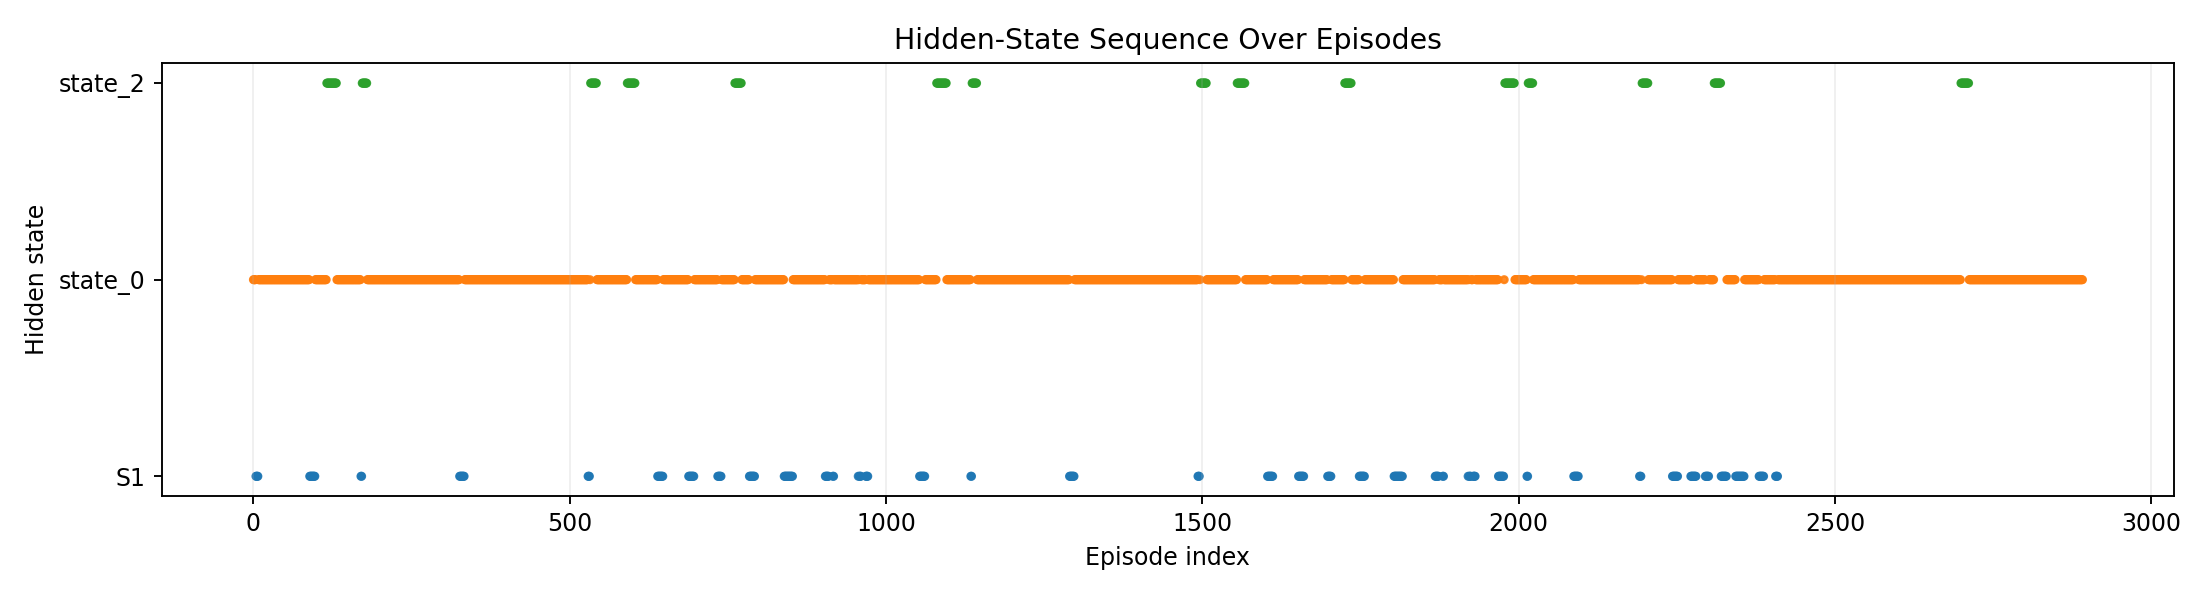

### state_probability_profile

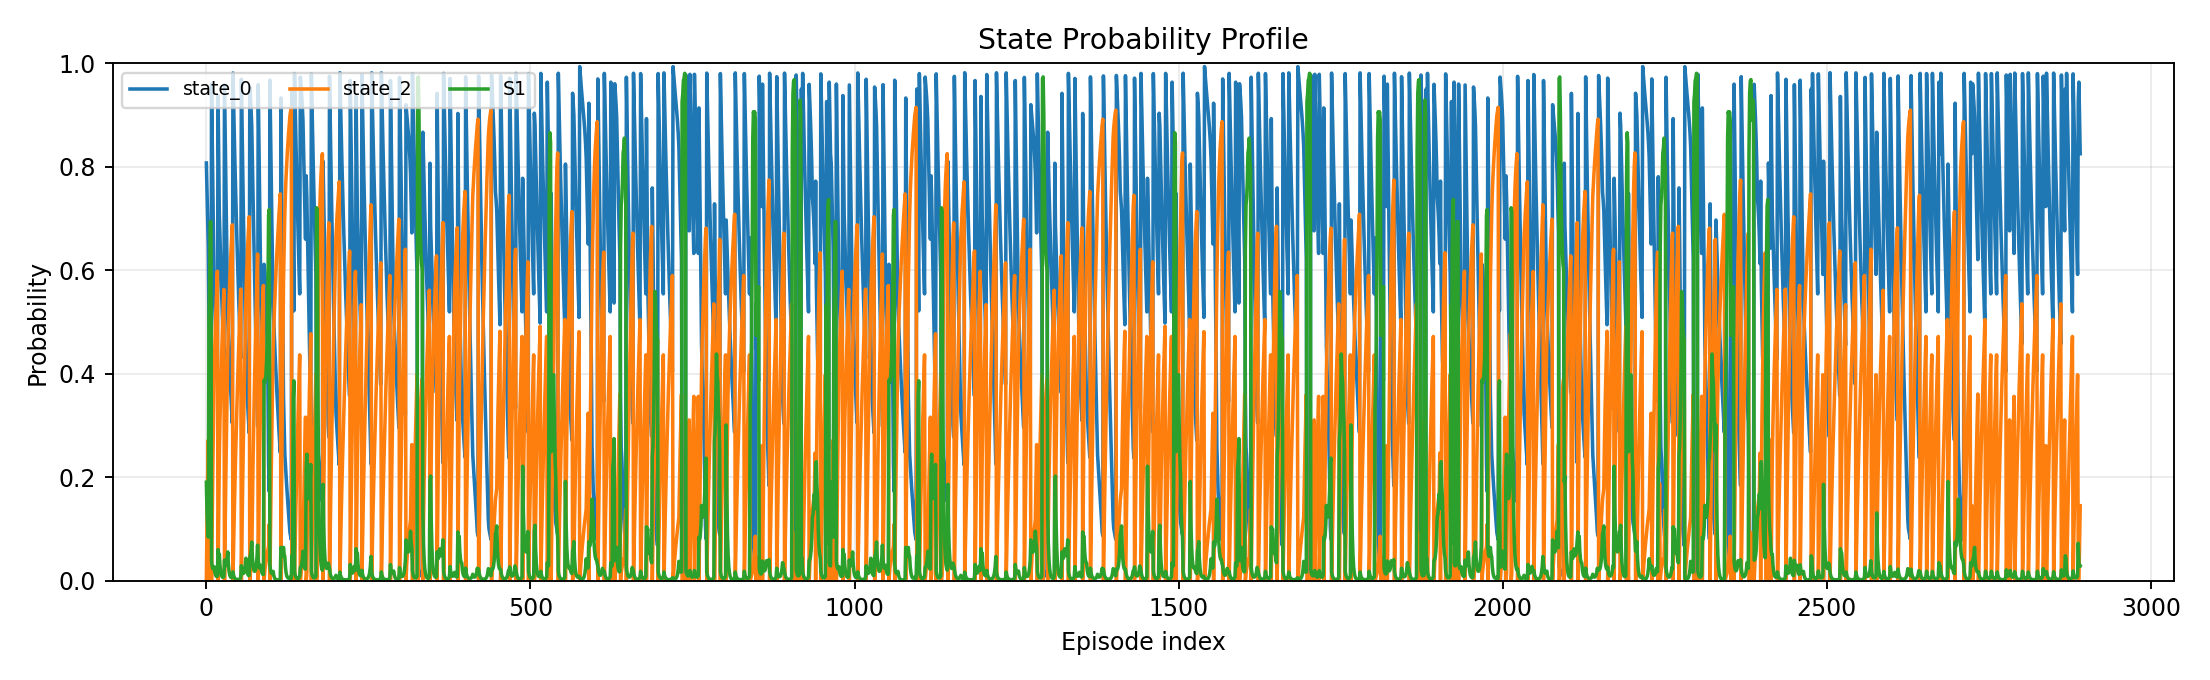

### transition_distribution

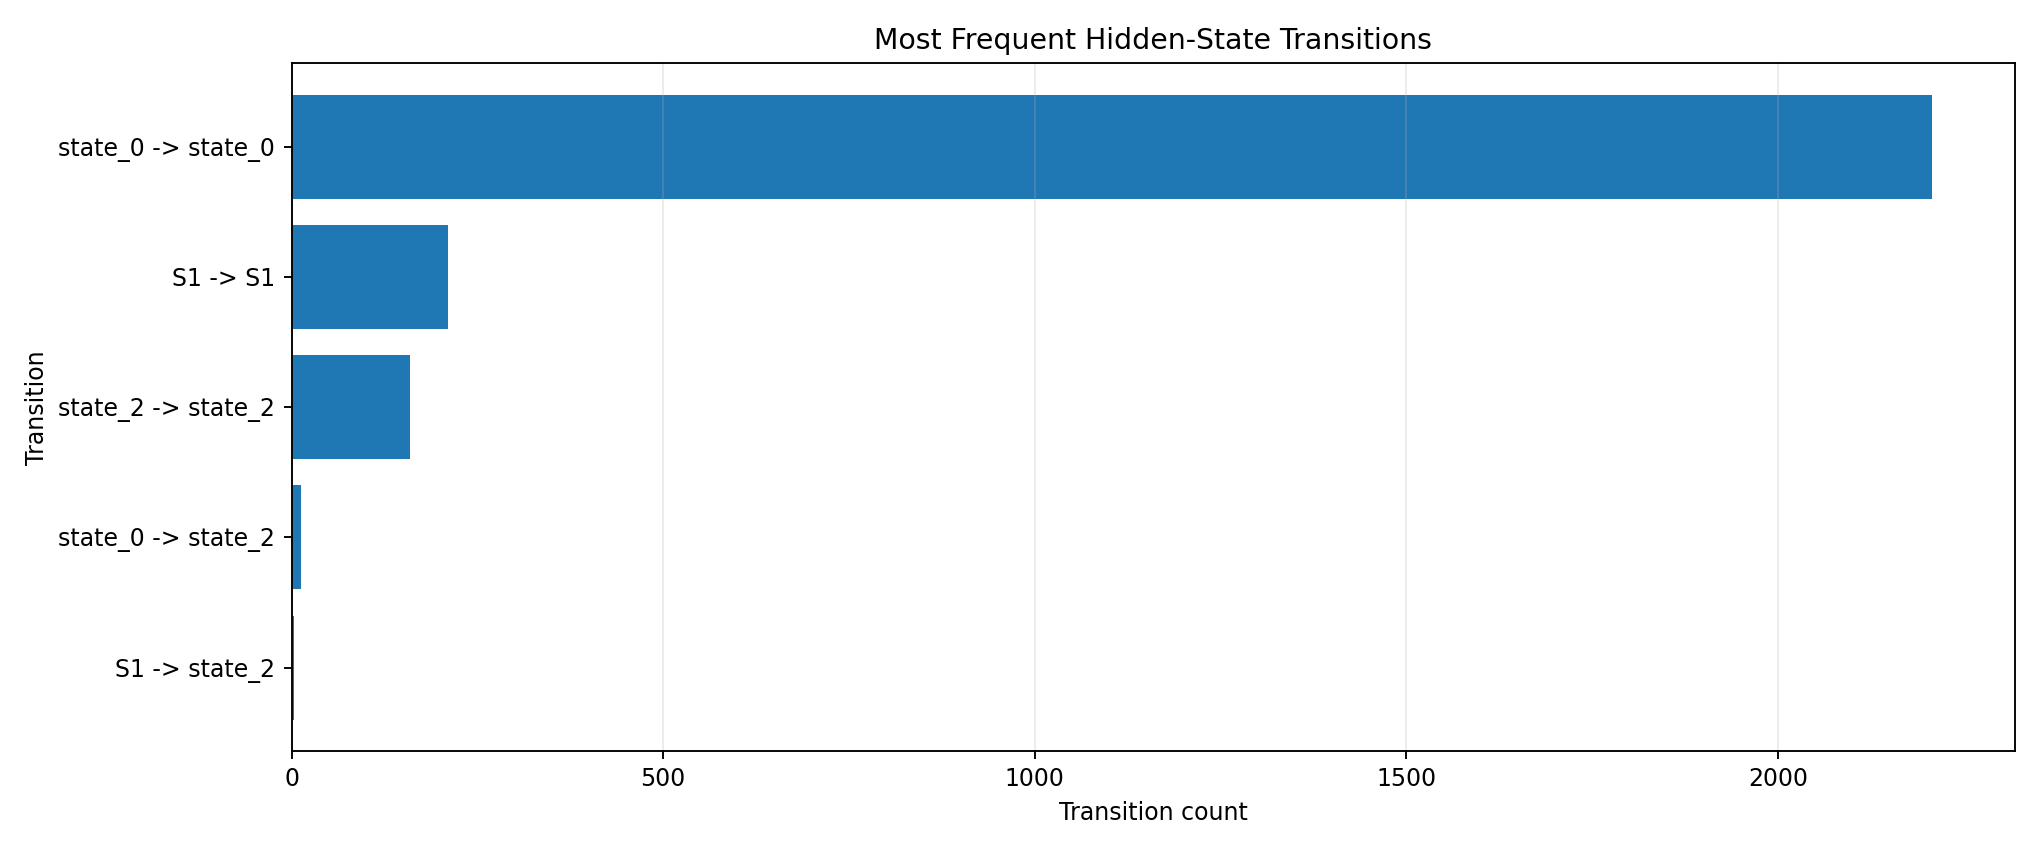

In [6]:
display(Markdown("## Plots"))
display_inverse_plots(artifacts.plot_paths)